In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings

from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss

warnings.filterwarnings("ignore")

np.random.seed(42)

print("Libraries imported successfully!")


Libraries imported successfully!


In [3]:
print("Downloading Fashion-MNIST...")
print("Please wait...")

fashion_mnist = fetch_openml(
    "Fashion-MNIST",
    version=1,
    as_frame=False
)

print("Dataset downloaded successfully!")

Please wait...
Dataset downloaded successfully!


In [4]:
X = fashion_mnist.data.astype("float32") / 255.0
y = fashion_mnist.target.astype("int64")

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)

Dataset shape: (70000, 784)
Labels shape: (70000,)


In [5]:
X_train = X[:10000]
y_train = y[:10000]

X_val = X[10000:12000]
y_val = y[10000:12000]

X_test = X[12000:14000]
y_test = y[12000:14000]

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)
print("Test data:", X_test.shape)

Training data: (10000, 784)
Validation data: (2000, 784)
Test data: (2000, 784)


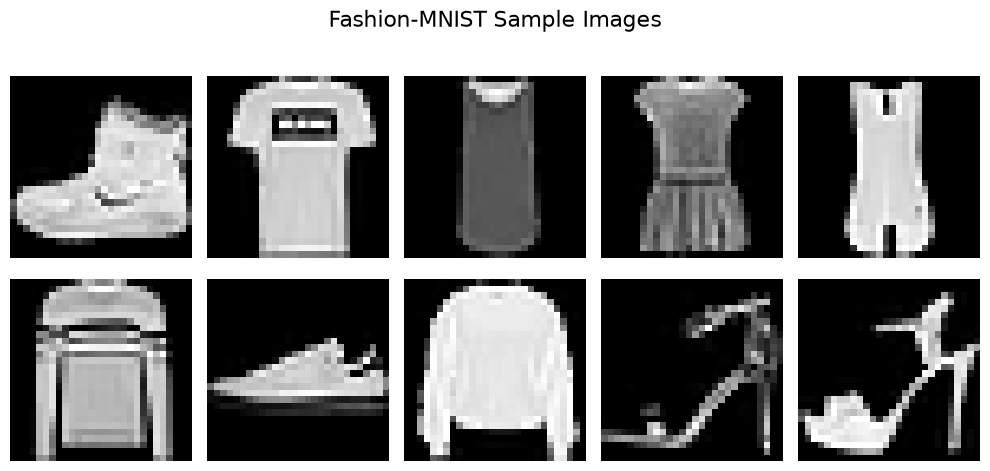

Sample images displayed successfully!


In [6]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(
        X_train[i].reshape(28, 28),
        cmap="gray"
    )
    plt.axis("off")

plt.suptitle(
    "Fashion-MNIST Sample Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

print("Sample images displayed successfully!")


In [7]:
models_config = {
    "M1 - Very Low": (32,),
    "M2 - Low": (64,),
    "M3 - Medium": (128, 128),
    "M4 - High": (256, 256),
    "M5 - Very High": (256, 256, 256)
}

print("Model complexity levels:")

for name, architecture in models_config.items():
    print(name, ":", architecture)


Model complexity levels:
M1 - Very Low : (32,)
M2 - Low : (64,)
M3 - Medium : (128, 128)
M4 - High : (256, 256)
M5 - Very High : (256, 256, 256)


In [8]:
def count_parameters(hidden_layers):

    layer_sizes = [784] + list(hidden_layers) + [10]

    parameters = 0

    for i in range(len(layer_sizes) - 1):

        parameters += (
            layer_sizes[i]
            * layer_sizes[i + 1]
        )

        parameters += layer_sizes[i + 1]

    return parameters


for name, architecture in models_config.items():

    print(
        name,
        ":",
        f"{count_parameters(architecture):,}",
        "parameters"
    )


M1 - Very Low : 25,450 parameters
M2 - Low : 50,890 parameters
M3 - Medium : 118,282 parameters
M4 - High : 269,322 parameters
M5 - Very High : 335,114 parameters


In [9]:
EPOCHS = 12
BATCH_SIZE = 128

results = []
histories = {}
trained_models = {}

print("Experiment settings:")
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)


Experiment settings:
Epochs: 12
Batch size: 128


In [10]:
print("=" * 60)
print("STARTING MODEL COMPLEXITY EXPERIMENT")
print("=" * 60)

for model_name, architecture in models_config.items():

    print("\n")
    print("-" * 60)
    print("Training:", model_name)
    print("Architecture:", architecture)
    print("-" * 60)

    model = MLPClassifier(
        hidden_layer_sizes=architecture,
        activation="relu",
        solver="adam",
        batch_size=BATCH_SIZE,
        learning_rate_init=0.001,
        max_iter=1,
        random_state=42,
        warm_start=False
    )

    parameters = count_parameters(
        architecture
    )

    history = {
        "accuracy": [],
        "val_accuracy": [],
        "loss": [],
        "val_loss": []
    }

    start_time = time.time()

    classes = np.arange(10)

    for epoch in range(EPOCHS):

        model.partial_fit(
            X_train,
            y_train,
            classes=classes
        )

        # Training predictions
        train_prob = model.predict_proba(
            X_train
        )

        train_pred = np.argmax(
            train_prob,
            axis=1
        )

        # Validation predictions
        val_prob = model.predict_proba(
            X_val
        )

        val_pred = np.argmax(
            val_prob,
            axis=1
        )

        # Accuracy
        train_accuracy = accuracy_score(
            y_train,
            train_pred
        )

        val_accuracy = accuracy_score(
            y_val,
            val_pred
        )

        # Loss
        train_loss = log_loss(
            y_train,
            train_prob,
            labels=classes
        )

        val_loss = log_loss(
            y_val,
            val_prob,
            labels=classes
        )

        # Save history
        history["accuracy"].append(
            train_accuracy
        )

        history["val_accuracy"].append(
            val_accuracy
        )

        history["loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        print(
            f"Epoch {epoch + 1:02d}/{EPOCHS} | "
            f"Train Accuracy: "
            f"{train_accuracy * 100:.2f}% | "
            f"Validation Accuracy: "
            f"{val_accuracy * 100:.2f}%"
        )

    # Test performance
    test_pred = model.predict(X_test)

    test_accuracy = accuracy_score(
        y_test,
        test_pred
    )

    # Final values
    train_accuracy = history["accuracy"][-1]
    val_accuracy = history["val_accuracy"][-1]

    train_loss = history["loss"][-1]
    val_loss = history["val_loss"][-1]

    generalization_gap = (
        train_accuracy - val_accuracy
    )

    training_time = time.time() - start_time

    # Save results
    results.append({
        "Model": model_name,
        "Architecture": str(architecture),
        "Parameters": parameters,
        "Training Accuracy": train_accuracy,
        "Validation Accuracy": val_accuracy,
        "Test Accuracy": test_accuracy,
        "Training Loss": train_loss,
        "Validation Loss": val_loss,
        "Generalization Gap": generalization_gap,
        "Training Time (sec)": training_time
    })

    histories[model_name] = history
    trained_models[model_name] = model

    print()
    print("Completed:", model_name)
    print("Parameters:", f"{parameters:,}")
    print(
        "Test Accuracy:",
        f"{test_accuracy * 100:.2f}%"
    )


STARTING MODEL COMPLEXITY EXPERIMENT


------------------------------------------------------------
Training: M1 - Very Low
Architecture: (32,)
------------------------------------------------------------
Epoch 01/12 | Train Accuracy: 72.95% | Validation Accuracy: 71.45%
Epoch 02/12 | Train Accuracy: 80.37% | Validation Accuracy: 80.90%
Epoch 03/12 | Train Accuracy: 81.78% | Validation Accuracy: 82.90%
Epoch 04/12 | Train Accuracy: 82.96% | Validation Accuracy: 83.30%
Epoch 05/12 | Train Accuracy: 83.77% | Validation Accuracy: 84.05%
Epoch 06/12 | Train Accuracy: 84.62% | Validation Accuracy: 84.35%
Epoch 07/12 | Train Accuracy: 85.35% | Validation Accuracy: 84.95%
Epoch 08/12 | Train Accuracy: 85.88% | Validation Accuracy: 85.25%
Epoch 09/12 | Train Accuracy: 86.31% | Validation Accuracy: 85.45%
Epoch 10/12 | Train Accuracy: 86.61% | Validation Accuracy: 85.90%
Epoch 11/12 | Train Accuracy: 86.94% | Validation Accuracy: 85.70%
Epoch 12/12 | Train Accuracy: 87.28% | Validation Accuracy

In [11]:
results_df = pd.DataFrame(results)

print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)

display(results_df)

FINAL RESULTS


,Model,Architecture,Parameters,Training Accuracy,Validation Accuracy,Test Accuracy,Training Loss,Validation Loss,Generalization Gap,Training Time (sec)
0,M1 - Very Low,"(32,)",25450,0.8728,0.8580,0.8430,0.378461,0.425937,0.0148,4.944937
1,M2 - Low,"(64,)",50890,0.8869,0.8630,0.8500,0.335646,0.407822,0.0239,6.210613
2,M3 - Medium,"(128, 128)",118282,0.8983,0.8775,0.8540,0.275324,0.373912,0.0208,8.091451
3,M4 - High,"(256, 256)",269322,0.9164,0.8730,0.8655,0.230346,0.387051,0.0434,13.522098
4,M5 - Very High,"(256, 256, 256)",335114,0.9104,0.8735,0.8615,0.244470,0.395341,0.0369,16.116504


In [12]:
formatted_results = results_df.copy()

formatted_results["Training Accuracy"] = (
    formatted_results["Training Accuracy"] * 100
).round(2)

formatted_results["Validation Accuracy"] = (
    formatted_results["Validation Accuracy"] * 100
).round(2)

formatted_results["Test Accuracy"] = (
    formatted_results["Test Accuracy"] * 100
).round(2)

formatted_results["Generalization Gap"] = (
    formatted_results["Generalization Gap"] * 100
).round(2)

formatted_results["Training Loss"] = (
    formatted_results["Training Loss"]
).round(4)

formatted_results["Validation Loss"] = (
    formatted_results["Validation Loss"]
).round(4)

formatted_results["Training Time (sec)"] = (
    formatted_results["Training Time (sec)"]
).round(2)

display(
    formatted_results[
        [
            "Model",
            "Parameters",
            "Training Accuracy",
            "Validation Accuracy",
            "Test Accuracy",
            "Generalization Gap",
            "Training Loss",
            "Validation Loss",
            "Training Time (sec)"
        ]
    ]
)


,Model,Parameters,Training Accuracy,Validation Accuracy,Test Accuracy,Generalization Gap,Training Loss,Validation Loss,Training Time (sec)
0,M1 - Very Low,25450,87.28,85.80,84.30,1.48,0.3785,0.4259,4.94
1,M2 - Low,50890,88.69,86.30,85.00,2.39,0.3356,0.4078,6.21
2,M3 - Medium,118282,89.83,87.75,85.40,2.08,0.2753,0.3739,8.09
3,M4 - High,269322,91.64,87.30,86.55,4.34,0.2303,0.3871,13.52
4,M5 - Very High,335114,91.04,87.35,86.15,3.69,0.2445,0.3953,16.12


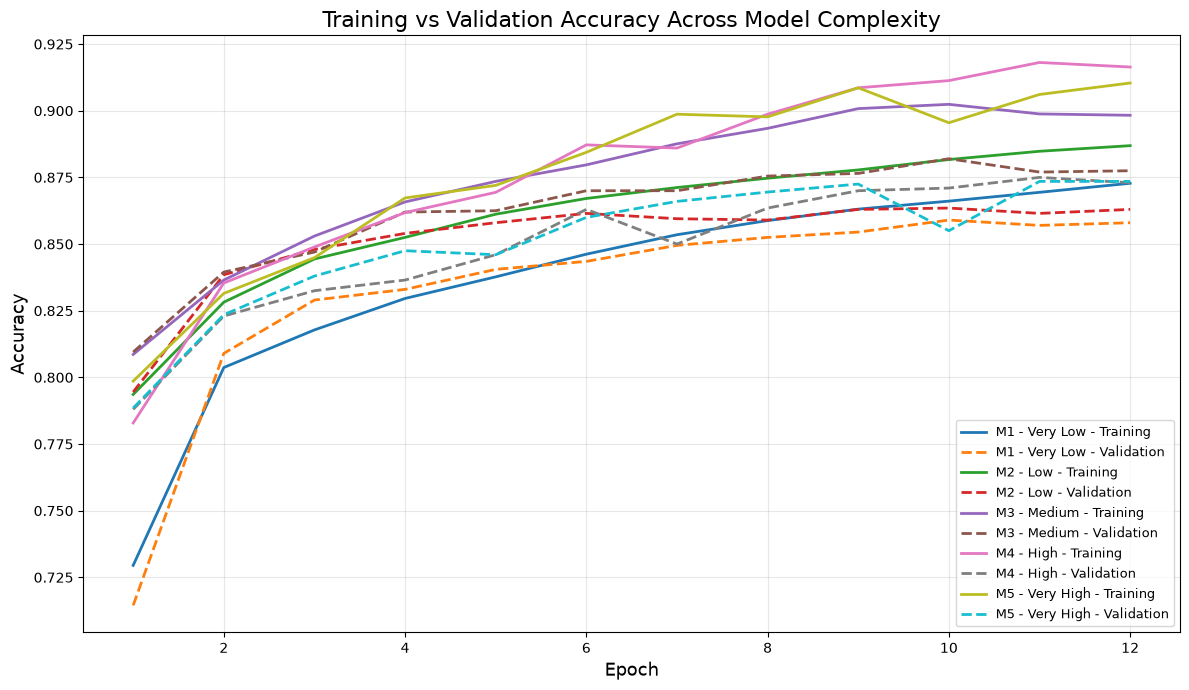

In [13]:
plt.figure(figsize=(12, 7))

for model_name, history in histories.items():

    epochs = range(
        1,
        len(history["accuracy"]) + 1
    )

    plt.plot(
        epochs,
        history["accuracy"],
        linewidth=2,
        label=model_name + " - Training"
    )

    plt.plot(
        epochs,
        history["val_accuracy"],
        linestyle="--",
        linewidth=2,
        label=model_name + " - Validation"
    )

plt.xlabel(
    "Epoch",
    fontsize=13
)

plt.ylabel(
    "Accuracy",
    fontsize=13
)

plt.title(
    "Training vs Validation Accuracy Across Model Complexity",
    fontsize=16
)

plt.legend(fontsize=9)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


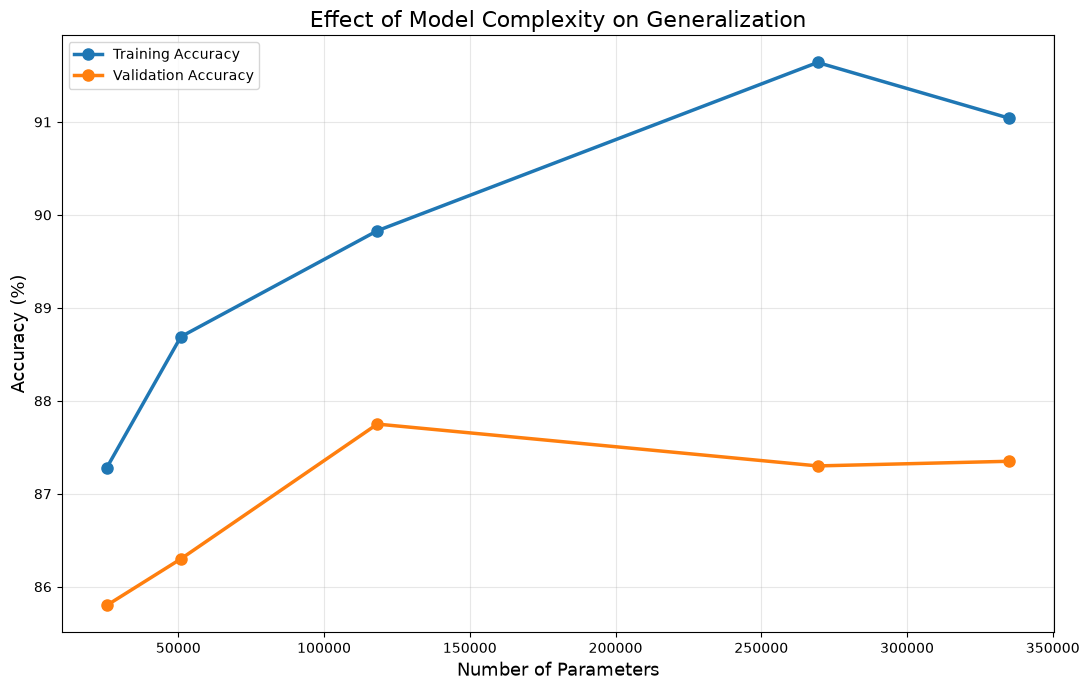

In [14]:
plt.figure(figsize=(11, 7))

plt.plot(
    results_df["Parameters"],
    results_df["Training Accuracy"] * 100,
    marker="o",
    linewidth=2.5,
    markersize=8,
    label="Training Accuracy"
)

plt.plot(
    results_df["Parameters"],
    results_df["Validation Accuracy"] * 100,
    marker="o",
    linewidth=2.5,
    markersize=8,
    label="Validation Accuracy"
)

plt.xlabel(
    "Number of Parameters",
    fontsize=13
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=13
)

plt.title(
    "Effect of Model Complexity on Generalization",
    fontsize=16
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


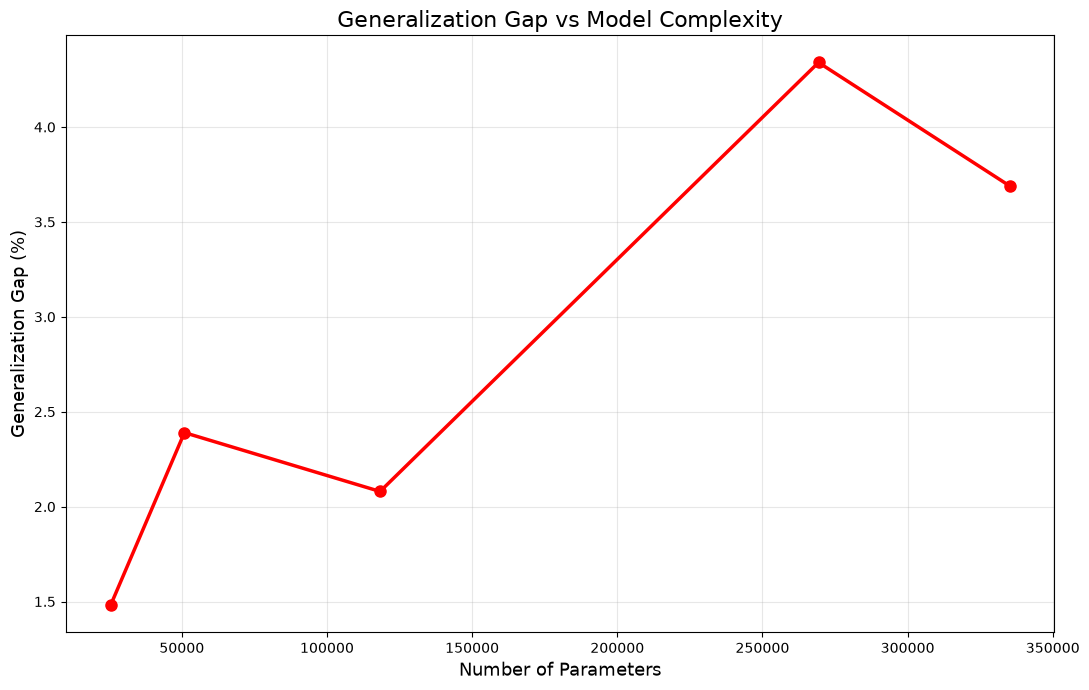

In [15]:
plt.figure(figsize=(11, 7))

plt.plot(
    results_df["Parameters"],
    results_df["Generalization Gap"] * 100,
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="red"
)

plt.xlabel(
    "Number of Parameters",
    fontsize=13
)

plt.ylabel(
    "Generalization Gap (%)",
    fontsize=13
)

plt.title(
    "Generalization Gap vs Model Complexity",
    fontsize=16
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


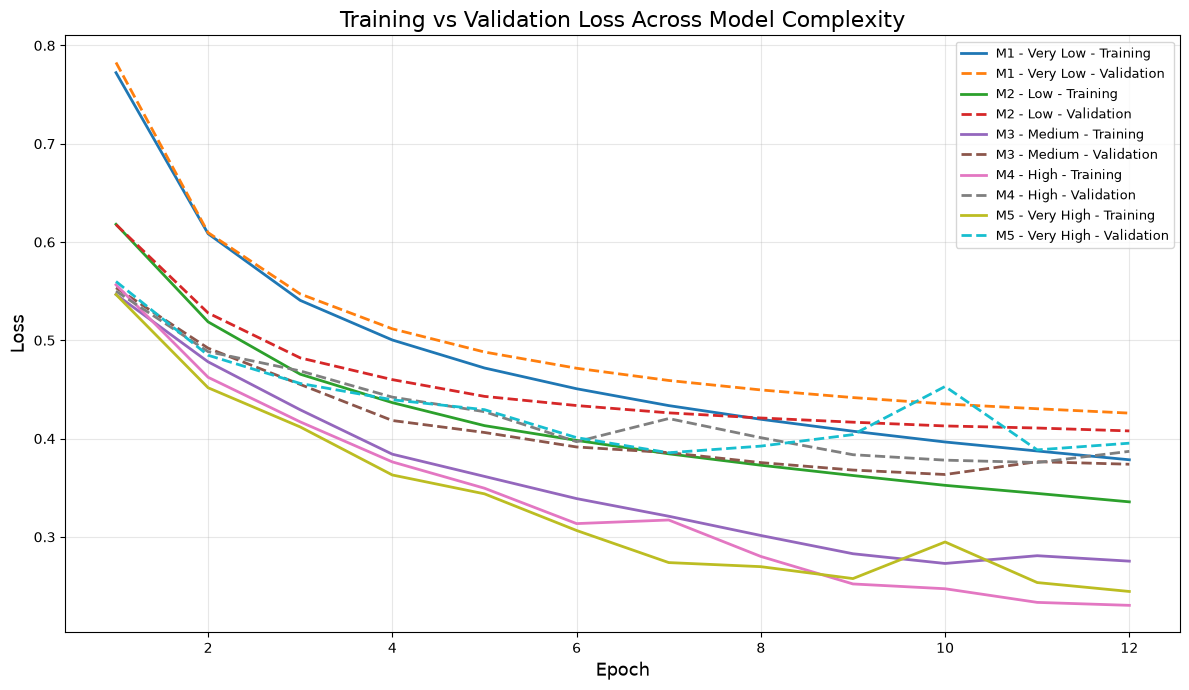

In [16]:
plt.figure(figsize=(12, 7))

for model_name, history in histories.items():

    epochs = range(
        1,
        len(history["loss"]) + 1
    )

    plt.plot(
        epochs,
        history["loss"],
        linewidth=2,
        label=model_name + " - Training"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        linestyle="--",
        linewidth=2,
        label=model_name + " - Validation"
    )

plt.xlabel(
    "Epoch",
    fontsize=13
)

plt.ylabel(
    "Loss",
    fontsize=13
)

plt.title(
    "Training vs Validation Loss Across Model Complexity",
    fontsize=16
)

plt.legend(fontsize=9)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


In [17]:
best_index = results_df[
    "Validation Accuracy"
].idxmax()

best_model = results_df.loc[
    best_index
]

print("=" * 60)
print("BEST VALIDATION PERFORMANCE")
print("=" * 60)

print(
    "Model:",
    best_model["Model"]
)

print(
    "Parameters:",
    f"{int(best_model['Parameters']):,}"
)

print(
    "Validation Accuracy:",
    f"{best_model['Validation Accuracy'] * 100:.2f}%"
)

print(
    "Test Accuracy:",
    f"{best_model['Test Accuracy'] * 100:.2f}%"
)

print(
    "Generalization Gap:",
    f"{best_model['Generalization Gap'] * 100:.2f}%"
)


BEST VALIDATION PERFORMANCE
Model: M3 - Medium
Parameters: 118,282
Validation Accuracy: 87.75%
Test Accuracy: 85.40%
Generalization Gap: 2.08%


In [18]:
print("=" * 60)
print("DIMINISHING RETURNS ANALYSIS")
print("=" * 60)

for i in range(1, len(results_df)):

    previous_accuracy = results_df.loc[
        i - 1,
        "Validation Accuracy"
    ]

    current_accuracy = results_df.loc[
        i,
        "Validation Accuracy"
    ]

    improvement = (
        current_accuracy - previous_accuracy
    ) * 100

    previous_params = results_df.loc[
        i - 1,
        "Parameters"
    ]

    current_params = results_df.loc[
        i,
        "Parameters"
    ]

    print(
        "\n",
        results_df.loc[i, "Model"]
    )

    print(
        "Parameter increase:",
        f"{previous_params:,} → {current_params:,}"
    )

    print(
        "Validation accuracy change:",
        f"{improvement:+.2f} percentage points"
    )


DIMINISHING RETURNS ANALYSIS

 M2 - Low
Parameter increase: 25,450 → 50,890
Validation accuracy change: +0.50 percentage points

 M3 - Medium
Parameter increase: 50,890 → 118,282
Validation accuracy change: +1.45 percentage points

 M4 - High
Parameter increase: 118,282 → 269,322
Validation accuracy change: -0.45 percentage points

 M5 - Very High
Parameter increase: 269,322 → 335,114
Validation accuracy change: +0.05 percentage points


In [19]:
print("=" * 60)
print("OVERFITTING ANALYSIS")
print("=" * 60)

for _, row in results_df.iterrows():

    gap = (
        row["Generalization Gap"] * 100
    )

    print(
        row["Model"],
        ":",
        f"Generalization Gap = {gap:.2f}%"
    )


OVERFITTING ANALYSIS
M1 - Very Low : Generalization Gap = 1.48%
M2 - Low : Generalization Gap = 2.39%
M3 - Medium : Generalization Gap = 2.08%
M4 - High : Generalization Gap = 4.34%
M5 - Very High : Generalization Gap = 3.69%


In [20]:
best_model_name = results_df.loc[
    results_df["Validation Accuracy"].idxmax(),
    "Model"
]

best_val_accuracy = (
    results_df["Validation Accuracy"].max()
    * 100
)

last_model = results_df.iloc[-1]

last_val_accuracy = (
    last_model["Validation Accuracy"]
    * 100
)

print("=" * 60)
print("EXPERIMENT INTERPRETATION")
print("=" * 60)

print(
    "\nHighest validation accuracy:",
    f"{best_val_accuracy:.2f}%",
    "(" + best_model_name + ")"
)

print(
    "Highest-complexity validation accuracy:",
    f"{last_val_accuracy:.2f}%"
)

if last_val_accuracy < best_val_accuracy:

    print(
        "\nObservation:"
    )

    print(
        "The highest-complexity model did not "
        "achieve the highest validation accuracy."
    )

    print(
        "This suggests that increasing complexity "
        "beyond a certain point did not improve "
        "validation performance in this experiment."
    )

else:

    print(
        "\nObservation:"
    )

    print(
        "Validation accuracy did not decrease "
        "at the highest tested complexity."
    )


EXPERIMENT INTERPRETATION

Highest validation accuracy: 87.75% (M3 - Medium)
Highest-complexity validation accuracy: 87.35%

Observation:
The highest-complexity model did not achieve the highest validation accuracy.
This suggests that increasing complexity beyond a certain point did not improve validation performance in this experiment.


In [21]:
results_df.to_csv(
    "model_complexity_results.csv",
    index=False
)

print(
    "Results saved successfully!"
)

print(
    "File: model_complexity_results.csv"
)


Results saved successfully!
File: model_complexity_results.csv
